In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath("."))
sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../"))

In [2]:
import numpy as np
np.set_printoptions(linewidth=np.inf, precision=4, suppress=True, threshold=sys.maxsize)
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.graph_objects as go
import functools
import scipy

In [3]:
from desc.io import load

eq = load("./equilibria/desc-eq-HBT_105995_06.h5")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


DESC version 0.13.0,using JAX backend, jax version=0.4.30, jaxlib version=0.4.30, dtype=float64
Using device: CPU, with 17.01 GB available memory


In [4]:
from omfit_classes import omfit_eqdsk

filename = "./From-Jeff/HBT_105995_06.eqdsk"
tokamaker = omfit_eqdsk.OMFITgeqdsk(filename)
# populate aux and flux-surface quantities
tokamaker.addAuxQuantities()
tokamaker.addFluxSurfaces(levels=list(np.linspace(0, 1, 129)))
tokamaker["fluxSurfaces"].surfAvg()

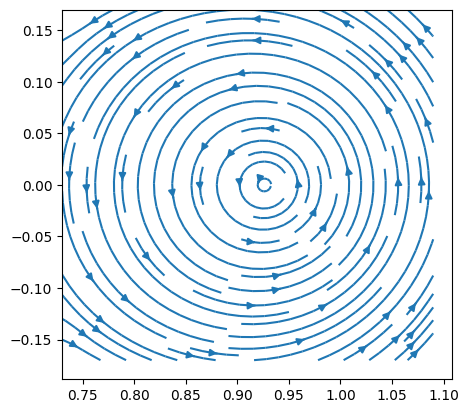

In [5]:
R = tokamaker["AuxQuantities"]["R"]
Z = tokamaker["AuxQuantities"]["Z"]

Br = tokamaker["AuxQuantities"]["Br"]
Bz = tokamaker["AuxQuantities"]["Bz"]
Bt = tokamaker["AuxQuantities"]["Bt"]

Jr = tokamaker["AuxQuantities"]["Jr"]
Jz = tokamaker["AuxQuantities"]["Jz"]
Jt = tokamaker["AuxQuantities"]["Jt"]
R, Z = np.meshgrid(R, Z)
plt.streamplot(R, Z, Br, Bz)
plt.gca().set_aspect("equal")

In [6]:
from desc.grid import LinearGrid

nrho = 50
ntheta = 50
data = eq.compute(
    ["B", "J", "R", "Z"], grid=LinearGrid(rho=nrho, theta=ntheta, zeta=0, endpoint=True)
)

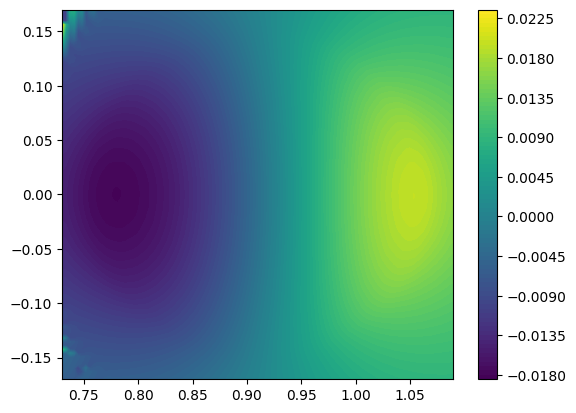

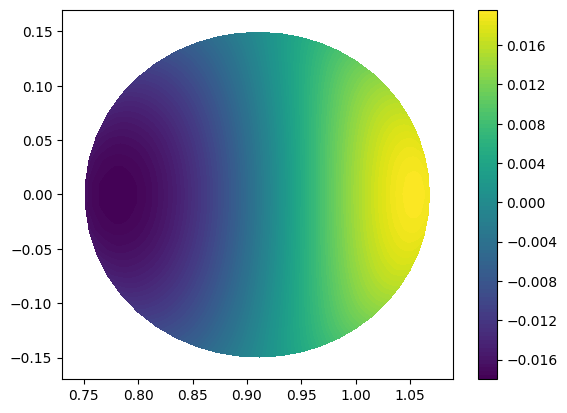

In [21]:
plt.contourf(R, Z, Bz, levels=100)
plt.colorbar()
plt.gca().set_aspect("equal")

plt.figure()
plt.contourf(
    data["R"].reshape(nrho, ntheta),
    data["Z"].reshape(nrho, ntheta),
    data["B"][:, 2].reshape(nrho, ntheta),
    levels=100,
)
plt.colorbar()
plt.xlim(R.min(), R.max())
plt.ylim(Z.min(), Z.max())
plt.gca().set_aspect("equal")

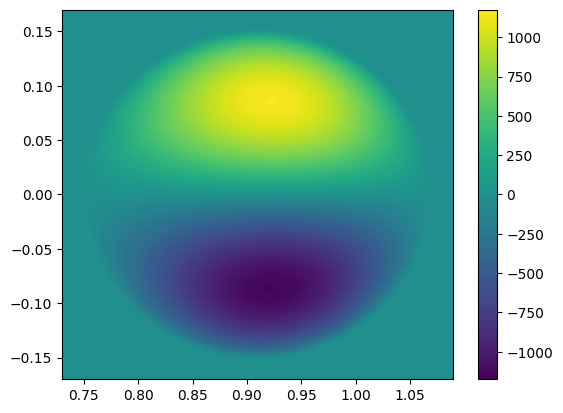

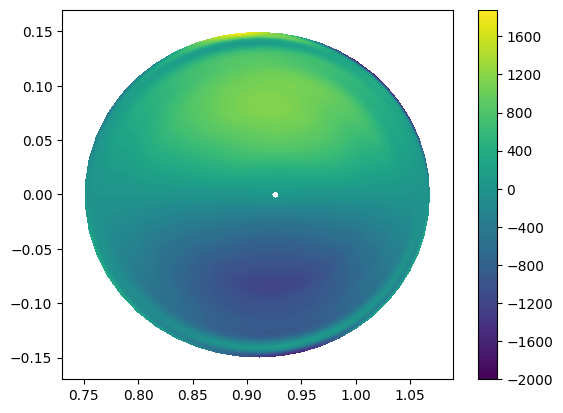

In [20]:
plt.contourf(R, Z, Jr, levels=100)
plt.gca().set_aspect("equal")
plt.colorbar()

plt.figure()
plt.contourf(
    data["R"].reshape(nrho, ntheta),
    data["Z"].reshape(nrho, ntheta),
    data["J"][:, 0].reshape(nrho, ntheta),
    levels=100,
)
plt.colorbar()
plt.xlim(R.min(), R.max())
plt.ylim(Z.min(), Z.max())
plt.gca().set_aspect("equal")